# Chapter 4 – Results: tables and figures

Bachelor's thesis *Off-Grid Integration in PyPSA-Earth – A Case Study for Decentralised Energy Systems*
OTH Regensburg | Supervisors: Anton Achhammer, Prof. Michael Sterner

This notebook regenerates every table and figure in Chapter 4 directly from the
PyPSA-Earth simulation outputs, so that each number in the thesis text can be
traced back to the run that produced it.

**Inputs**

**Inputs**

| File | Produced by |
|---|---|
| `elec_s_47_ec_lcopt_Co2L-3h_offgrid.nc` | `scripts/build_offgrid.py` (Snakemake rule `build_offgrid`) |
| `offgrid_results_s_47_lcopt_Co2L-3h.csv` | `scripts/build_offgrid.py` |
| `village_minigrid_results.csv` | `village_minigrids.py` (standalone) |

Repository: <https://github.com/zarga-code/pypsa-earth/tree/feat/implement-offgrid>

**Contents**

- Section 0 – setup, data loading, integrity checks
- Section 4.1 – county-level results (`Table: county-level off-grid results`)
- *(further tables and figures added incrementally)*

## 0 Setup

In [ ]:
import os
import json

import numpy as np
import pandas as pd
import pypsa

# Paths are relative to the PyPSA-Earth repository root.
NETWORK_FILE = "results/networks/elec_s_47_ec_lcopt_Co2L-3h_offgrid.nc"
COUNTY_CSV = "results/offgrid_results_s_47_lcopt_Co2L-3h.csv"
SHAPES_FILE = "resources/shapes/gadm_shapes.geojson"
VILLAGE_CSV = "village_minigrid_results.csv"
FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

### 0.1 Load network and results

`n.meta` carries the full `config.yaml` used for the run, so the parameter values
reported in the methodology chapter are read from the network file itself rather
than typed in by hand.

In [22]:
n = pypsa.Network(NETWORK_FILE)
county = pd.read_csv(COUNTY_CSV)

# snapshot weightings: the run uses 3-hourly resolution (opts "Co2L-3h"),
# so energy = power * weighting, NOT a plain .sum() over snapshots.
W = n.snapshot_weightings.generators

cfg = n.meta["offgrid"]
if isinstance(cfg, str):
    cfg = json.loads(cfg)

r_ = cfg["discount_rate"]
L_ = cfg["asset_lifetime"]
ANNUITY = r_ * (1 + r_) ** L_ / ((1 + r_) ** L_ - 1)

offgrid_buses = [b for b in n.buses.index if b.startswith("offgrid_")]
regions = [b.replace("offgrid_", "") for b in offgrid_buses]

print(f"network         : {os.path.basename(NETWORK_FILE)}")
print(
    f"buses           : {len(n.buses)} "
    f"({len(n.buses) - len(offgrid_buses)} main grid + {len(offgrid_buses)} off-grid)"
)
print(f"lines           : {len(n.lines)}")
print(f"snapshots       : {len(n.snapshots)} x {W.unique()[0]:.0f} h = {W.sum():.0f} h")
print(
    f"discount rate   : {r_:.3f}  |  lifetime: {L_} a  |  annuity factor: {ANNUITY:.5f}"
)
print(f"demand          : {cfg['kwh_per_person_yr']} kWh/person/a")
print(
    f"CAPEX           : solar {cfg['solar_capex']} EUR/kW | "
    f"battery {cfg['battery_capex_kwh']} EUR/kWh x {cfg['battery_max_hours']} h | "
    f"diesel {cfg['diesel_capex']} EUR/kW"
)
print(f"off-grid regions: {regions}")

INFO:pypsa.io:Imported network elec_s_47_ec_lcopt_Co2L-3h_offgrid.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


network         : elec_s_47_ec_lcopt_Co2L-3h_offgrid.nc
buses           : 149 (141 main grid + 8 off-grid)
lines           : 52
snapshots       : 2920 x 3 h = 8760 h
discount rate   : 0.071  |  lifetime: 20 a  |  annuity factor: 0.09513
demand          : 60 kWh/person/a
CAPEX           : solar 800 EUR/kW | battery 250 EUR/kWh x 6 h | diesel 400 EUR/kW
off-grid regions: ['KE.7_1', 'KE.8_1', 'KE.18_1', 'KE.24_1', 'KE.27_1', 'KE.37_1', 'KE.43_1', 'KE.46_1']


### 0.2 County names

GADM IDs are resolved from `gadm_shapes.geojson` rather than hard-coded, to avoid
mislabelling counties in the thesis text. If the shapes file is not available the
notebook falls back to the raw GADM IDs.

In [23]:
COUNTY_NAMES = {}
try:
    import geopandas as gpd

    _shapes = gpd.read_file(SHAPES_FILE)
    _namecol = next(
        (c for c in ["NAME_1", "name", "GADM_NAME", "NAME"] if c in _shapes.columns),
        None,
    )
    if _namecol:
        COUNTY_NAMES = dict(zip(_shapes["GADM_ID"], _shapes[_namecol]))
        print(f"resolved {len(COUNTY_NAMES)} county names from column '{_namecol}'")
except Exception as exc:  # noqa: BLE001
    print(f"county names unavailable ({exc}); falling back to GADM IDs")


def county_name(gadm_id):
    return COUNTY_NAMES.get(gadm_id, gadm_id)


for r in regions:
    print(f"  {r:10s} -> {county_name(r)}")

  KE.7_1     -> KE.7_1
  KE.8_1     -> KE.8_1
  KE.18_1    -> KE.18_1
  KE.24_1    -> KE.24_1
  KE.27_1    -> KE.27_1
  KE.37_1    -> KE.37_1
  KE.43_1    -> KE.43_1
  KE.46_1    -> KE.46_1


### 0.3 Integrity checks

Three things are verified before any number is used in the thesis:

1. the load actually present in the network equals the demand model
   $E_{\mathrm{annual}} = P \cdot 60\,\mathrm{kWh/a}$;
2. the capacities in the results CSV equal the optimised capacities in the network;
3. no load shedding occurred, i.e. demand is fully served in every snapshot.

In [24]:
check = []
for r in regions:
    pop = int(county.set_index("region").loc[r, "population"])
    check.append(
        {
            "region": r,
            "load_network_MWh": (n.loads_t.p_set[f"load_{r}"] * W).sum(),
            "load_model_MWh": pop * cfg["kwh_per_person_yr"] / 1000,
            "solar_MWh": (n.generators_t.p[f"solar_{r}"] * W).sum(),
            "diesel_MWh": (n.generators_t.p[f"diesel_{r}"] * W).sum(),
            "shed_MWh": (n.generators_t.p[f"shedding_{r}"] * W).sum(),
            "solar_MW_network": n.generators.loc[f"solar_{r}", "p_nom_opt"],
            "solar_MW_csv": county.set_index("region").loc[r, "solar_kw"] / 1000,
        }
    )

check = pd.DataFrame(check).set_index("region")
check["load_delta"] = check.load_network_MWh - check.load_model_MWh
check["solar_delta"] = check.solar_MW_network - check.solar_MW_csv

display(check.round(3))

assert check.load_delta.abs().max() < 1e-6, "load does not match demand model"
assert check.solar_delta.abs().max() < 1e-3, "CSV capacities do not match network"
assert check.shed_MWh.max() == 0, "load shedding occurred"
print("OK - network, results CSV and demand model are consistent; no load shedding.")

,load_network_MWh,load_model_MWh,solar_MWh,diesel_MWh,shed_MWh,solar_MW_network,solar_MW_csv,load_delta,solar_delta
region,,,,,,,,,
KE.7_1,90944.64,90944.64,94662.067,1726.279,0.0,51.449,51.449,0.0,0.0
KE.8_1,69485.10,69485.10,71284.055,2318.812,0.0,41.089,41.089,0.0,-0.0
KE.18_1,74236.02,74236.02,76767.633,1879.013,0.0,42.290,42.290,-0.0,0.0
KE.24_1,155950.08,155950.08,160460.944,4643.729,0.0,97.745,97.745,0.0,0.0
KE.27_1,68262.54,68262.54,69583.619,2674.039,0.0,40.936,40.936,0.0,-0.0
KE.37_1,19163.52,19163.52,19964.762,346.073,0.0,11.255,11.256,0.0,-0.0
KE.43_1,72569.34,72569.34,75394.135,1537.655,0.0,37.356,37.356,0.0,-0.0
KE.46_1,101719.50,101719.50,105508.764,2234.324,0.0,62.102,62.102,0.0,0.0


OK - network, results CSV and demand model are consistent; no load shedding.


---

## 4.1 County-level results

Each of the eight counties identified by the geo-logic screening (C1–C3) is
modelled as a **single** isolated mini-grid at the county centroid, with the
entire county population aggregated into one demand node.

In [25]:
t41 = county.copy()
t41["county"] = t41.region.map(county_name)
t41["solar_mw"] = t41.solar_kw / 1000
t41["battery_mw"] = t41.battery_kw / 1000
t41["battery_mwh"] = t41.battery_kwh / 1000
t41["diesel_mw"] = t41.diesel_kw / 1000
t41["elec_pct"] = t41.elec_rate * 100
t41["capex_meur"] = t41.capex_total_keur / 1000

cols = [
    "region",
    "county",
    "population",
    "distance_km",
    "elec_pct",
    "solar_mw",
    "battery_mw",
    "battery_mwh",
    "diesel_mw",
    "lcoe_eur_kwh",
    "autarky_pct",
    "co2_t_yr",
    "capex_meur",
    "total_cost_keur_yr",
    "grid_total_keur_yr",
    "offgrid_cheaper",
]
display(t41[cols].round(3))

,region,county,population,distance_km,elec_pct,solar_mw,battery_mw,battery_mwh,diesel_mw,lcoe_eur_kwh,autarky_pct,co2_t_yr,capex_meur,total_cost_keur_yr,grid_total_keur_yr,offgrid_cheaper
0,KE.7_1,KE.7_1,1515744,66.4,11.6,51.449,73.976,443.858,1.500,0.182,98.2,1226.57,152.724,16567.4,129.0,False
1,KE.8_1,KE.8_1,1158085,55.2,3.3,41.089,57.121,342.726,2.654,0.191,96.8,1647.58,119.614,13259.8,108.0,False
2,KE.18_1,KE.18_1,1237267,92.7,4.8,42.290,60.518,363.106,2.015,0.185,97.6,1335.09,125.414,13740.2,178.4,False
3,KE.24_1,KE.24_1,2599168,278.9,2.5,97.745,126.021,756.127,4.006,0.190,97.2,3299.49,268.830,29638.6,527.9,False
4,KE.27_1,KE.27_1,1137709,60.0,5.3,40.936,56.019,336.114,3.079,0.193,96.3,1899.98,118.009,13195.9,117.0,False
5,KE.37_1,KE.37_1,319392,105.1,6.2,11.256,15.632,93.790,0.418,0.184,98.3,245.89,32.619,3531.3,201.6,False
6,KE.43_1,KE.43_1,1209489,150.5,2.4,37.356,59.855,359.132,1.659,0.181,98.0,1092.54,120.331,13104.8,286.9,False
7,KE.46_1,KE.46_1,1695325,246.4,3.4,62.102,82.222,493.332,2.177,0.186,97.9,1587.55,173.886,18941.8,466.9,False


### Summary statistics quoted in the thesis text

Every range stated in Section 4.1 of the thesis is printed here so it can be
copied without transcription errors.

In [26]:
lo, hi = t41.solar_mw.idxmin(), t41.solar_mw.idxmax()

print(f"counties identified : {len(t41)}")
print(
    f"population          : {t41.population.min():,} - {t41.population.max():,} "
    f"(total {t41.population.sum():,})"
)
print(
    f"grid distance       : {t41.distance_km.min():.1f} - {t41.distance_km.max():.1f} km"
)
print(f"electrification rate: {t41.elec_pct.min():.1f} - {t41.elec_pct.max():.1f} %")
print(
    f"solar capacity      : {t41.solar_mw.min():.1f} MW ({t41.loc[lo, 'region']}, "
    f"{county_name(t41.loc[lo, 'region'])}) - "
    f"{t41.solar_mw.max():.1f} MW ({t41.loc[hi, 'region']}, "
    f"{county_name(t41.loc[hi, 'region'])})"
)
print(
    f"battery power       : {t41.battery_mw.min():.1f} - {t41.battery_mw.max():.1f} MW"
)
print(f"diesel capacity     : {t41.diesel_mw.min():.2f} - {t41.diesel_mw.max():.2f} MW")
print(
    f"LCOE                : {t41.lcoe_eur_kwh.min():.3f} - {t41.lcoe_eur_kwh.max():.3f} "
    f"EUR/kWh (mean {t41.lcoe_eur_kwh.mean():.3f})"
)
print(
    f"solar autarky       : {t41.autarky_pct.min():.1f} - {t41.autarky_pct.max():.1f} %"
)
print(f"CO2 (diesel backup) : {t41.co2_t_yr.sum():,.0f} t/a total")
print(
    f"total annual cost   : {t41.total_cost_keur_yr.min():,.1f} - "
    f"{t41.total_cost_keur_yr.max():,.1f} kEUR/a"
)
print(
    f"grid alternative    : {t41.grid_total_keur_yr.min():,.1f} - "
    f"{t41.grid_total_keur_yr.max():,.1f} kEUR/a"
)
print(f"off-grid cheaper    : {int(t41.offgrid_cheaper.sum())}/{len(t41)}")

counties identified : 8
population          : 319,392 - 2,599,168 (total 10,872,179)
grid distance       : 55.2 - 278.9 km
electrification rate: 2.4 - 11.6 %
solar capacity      : 11.3 MW (KE.37_1, KE.37_1) - 97.7 MW (KE.24_1, KE.24_1)
battery power       : 15.6 - 126.0 MW
diesel capacity     : 0.42 - 4.01 MW
LCOE                : 0.181 - 0.193 EUR/kWh (mean 0.186)
solar autarky       : 96.3 - 98.3 %
CO2 (diesel backup) : 12,335 t/a total
total annual cost   : 3,531.3 - 29,638.6 kEUR/a
grid alternative    : 108.0 - 527.9 kEUR/a
off-grid cheaper    : 0/8


### county-level off-grid results

In [39]:
# ── Table: county-level off-grid results ─────────────────────────
table_41 = pd.DataFrame(
    {
        "Population": t41.population,
        "Distance [km]": t41.distance_km.round(1),
        "Elec. rate [%]": t41.elec_pct.round(1),
        "Solar [MW]": t41.solar_mw.round(1),
        "Battery [MW]": t41.battery_mw.round(1),
        "Diesel [MW]": t41.diesel_mw.round(2),
        "LCOE [EUR/kWh]": t41.lcoe_eur_kwh.round(3),
        "Autarky [%]": t41.autarky_pct.round(1),
        "CO2 [t/a]": t41.co2_t_yr.round(0),
    }
).set_index(t41.region)
table_41.index.name = "Region"

table_41.loc["Total"] = [
    t41.population.sum(),
    np.nan,
    np.nan,
    round(t41.solar_mw.sum(), 1),
    round(t41.battery_mw.sum(), 1),
    round(t41.diesel_mw.sum(), 2),
    round(t41.lcoe_eur_kwh.mean(), 3),
    round(t41.autarky_pct.mean(), 1),
    round(t41.co2_t_yr.sum(), 0),
]
for _c in ["Population", "CO2 [t/a]"]:
    table_41[_c] = table_41[_c].astype("int64")

display(table_41)

,Population,Distance [km],Elec. rate [%],Solar [MW],Battery [MW],Diesel [MW],LCOE [EUR/kWh],Autarky [%],CO2 [t/a]
Region,,,,,,,,,
KE.7_1,1515744,66.4,11.6,51.4,74.0,1.50,0.182,98.2,1227
KE.8_1,1158085,55.2,3.3,41.1,57.1,2.65,0.191,96.8,1648
KE.18_1,1237267,92.7,4.8,42.3,60.5,2.02,0.185,97.6,1335
KE.24_1,2599168,278.9,2.5,97.7,126.0,4.01,0.190,97.2,3299
KE.27_1,1137709,60.0,5.3,40.9,56.0,3.08,0.193,96.3,1900
KE.37_1,319392,105.1,6.2,11.3,15.6,0.42,0.184,98.3,246
KE.43_1,1209489,150.5,2.4,37.4,59.9,1.66,0.181,98.0,1093
KE.46_1,1695325,246.4,3.4,62.1,82.2,2.18,0.186,97.9,1588
Total,10872179,NaN,NaN,384.2,531.4,17.51,0.186,97.5,12335


### Figure – CAPEX breakdown and annualised cost comparison

Left: total investment cost per county, split by technology. Right: annualised
total cost of the off-grid mini-grid against the grid-connection alternative
(`\ref{fig:capex-breakdown}`).

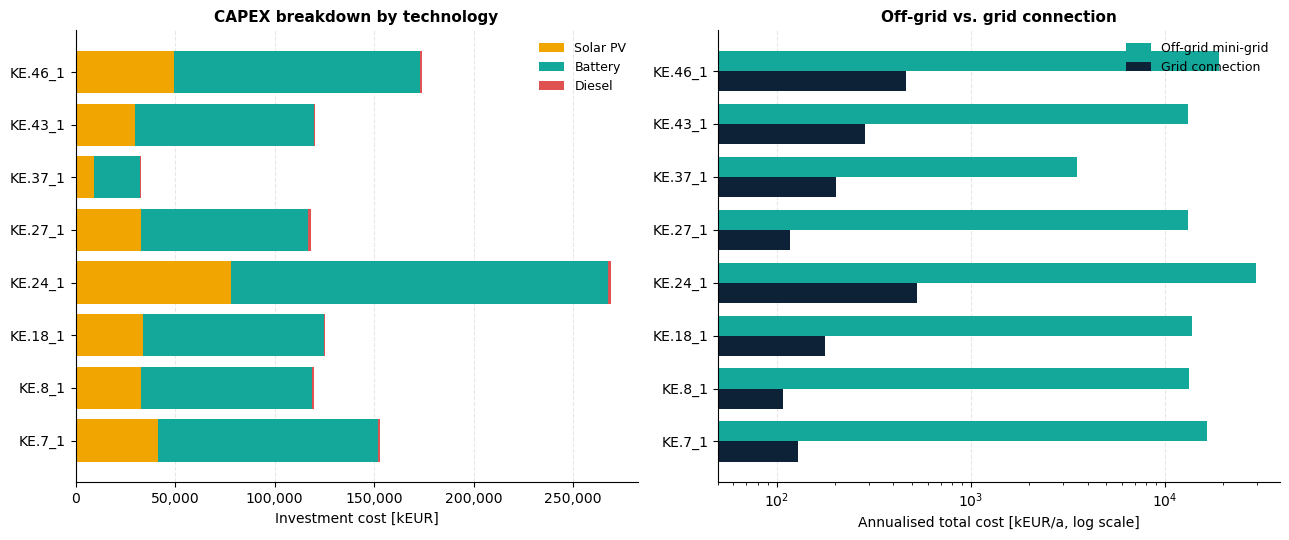

CAPEX by technology [kEUR]
 region  capex_solar_keur  capex_battery_keur  capex_diesel_keur  capex_total_keur
 KE.7_1           41159.4            110964.6              600.0          152724.0
 KE.8_1           32870.9             85681.4             1061.7          119614.0
KE.18_1           33831.9             90776.4              806.0          125414.4
KE.24_1           78195.7            189031.8             1602.6          268830.2
KE.27_1           32748.7             84028.6             1231.7          118009.0
KE.37_1            9004.4             23447.4              167.2           32618.9
KE.43_1           29884.6             89783.1              663.7          120331.3
KE.46_1           49681.8            123333.0              870.7          173885.5

share of total CAPEX
  capex_solar_keur      :    307.4 MEUR ( 27.7 %)
  capex_battery_keur    :    797.0 MEUR ( 71.7 %)
  capex_diesel_keur     :      7.0 MEUR (  0.6 %)

cost ratio off-grid / grid connection
0    128.4
1   

In [28]:
# ── Figure: CAPEX breakdown + annualised cost comparison ─────────
import matplotlib
import matplotlib.pyplot as plt

GRID_LOG = True  # log x-axis on the right panel (see note below)

f42 = t41.copy()
f42["capex_solar_keur"] = f42.solar_kw * cfg["solar_capex"] / 1000
f42["capex_battery_keur"] = f42.battery_kwh * cfg["battery_capex_kwh"] / 1000
f42["capex_diesel_keur"] = f42.diesel_kw * cfg["diesel_capex"] / 1000

# the reconstructed split must reproduce the CAPEX reported in the results CSV
assert np.allclose(
    f42.capex_solar_keur + f42.capex_battery_keur + f42.capex_diesel_keur,
    f42.capex_total_keur,
    rtol=1e-3,
)

C_SOLAR, C_BATT, C_DIES = "#f0a500", "#14a89a", "#e05252"
C_OFF, C_GRID = "#14a89a", "#0D2137"

y = np.arange(len(f42))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.barh(y, f42.capex_solar_keur, color=C_SOLAR, label="Solar PV")
ax1.barh(
    y, f42.capex_battery_keur, left=f42.capex_solar_keur, color=C_BATT, label="Battery"
)
ax1.barh(
    y,
    f42.capex_diesel_keur,
    left=f42.capex_solar_keur + f42.capex_battery_keur,
    color=C_DIES,
    label="Diesel",
)
ax1.set_yticks(y)
ax1.set_yticklabels(f42.region)
ax1.set_xlabel("Investment cost [kEUR]")
ax1.set_title("CAPEX breakdown by technology", fontsize=11, fontweight="bold")
ax1.legend(frameon=False, fontsize=9)
ax1.grid(axis="x", alpha=0.3, linestyle="--")
ax1.set_axisbelow(True)
ax1.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, p: f"{v:,.0f}"))

h = 0.38
ax2.barh(
    y + h / 2, f42.total_cost_keur_yr, height=h, color=C_OFF, label="Off-grid mini-grid"
)
ax2.barh(
    y - h / 2, f42.grid_total_keur_yr, height=h, color=C_GRID, label="Grid connection"
)
ax2.set_yticks(y)
ax2.set_yticklabels(f42.region)
ax2.set_title("Off-grid vs. grid connection", fontsize=11, fontweight="bold")
ax2.legend(frameon=False, fontsize=9)
ax2.grid(axis="x", alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)
if GRID_LOG:
    ax2.set_xscale("log")
    ax2.set_xlim(left=50)
    ax2.set_xlabel("Annualised total cost [kEUR/a, log scale]")
else:
    ax2.set_xlabel("Annualised total cost [kEUR/a]")
    ax2.xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda v, p: f"{v:,.0f}")
    )

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGDIR}/offgrid_costs.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/offgrid_costs.pdf", bbox_inches="tight")
plt.show()

print("CAPEX by technology [kEUR]")
print(
    f42[
        [
            "region",
            "capex_solar_keur",
            "capex_battery_keur",
            "capex_diesel_keur",
            "capex_total_keur",
        ]
    ]
    .round(1)
    .to_string(index=False)
)

_tot = f42[["capex_solar_keur", "capex_battery_keur", "capex_diesel_keur"]].sum()
print("\nshare of total CAPEX")
for _k, _v in _tot.items():
    print(f"  {_k:22s}: {_v/1000:8.1f} MEUR ({_v/_tot.sum()*100:5.1f} %)")

print("\ncost ratio off-grid / grid connection")
print((f42.total_cost_keur_yr / f42.grid_total_keur_yr).round(1).to_string())

### Figure – KPI comparison across counties

LCOE, installed solar capacity, solar autarky and diesel-related CO$_2$ emissions
for the eight identified off-grid counties (`\ref{fig:offgrid-kpis}`).

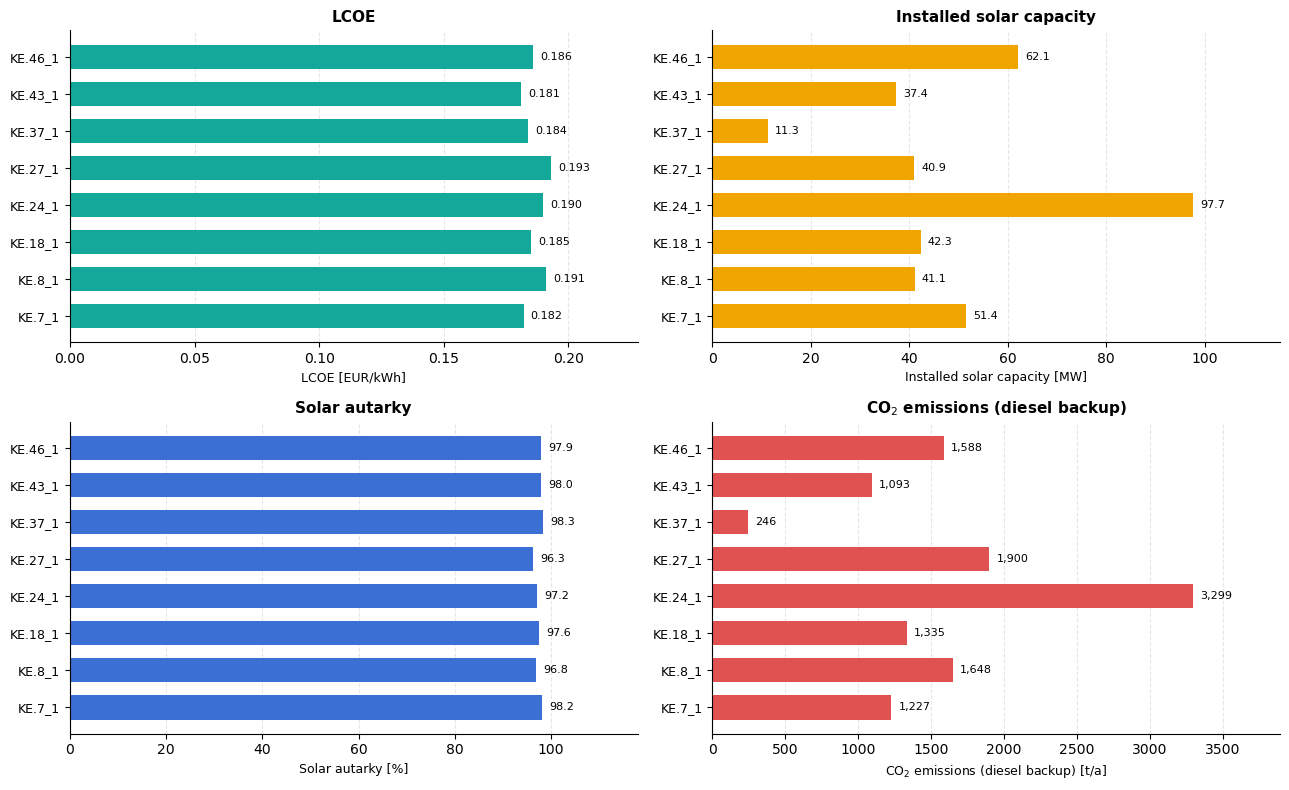

KPI ranges across the eight counties
  LCOE                               [EUR/kWh]  min      0.181 | max      0.193 | mean      0.186
  Installed solar capacity           [MW]       min     11.255 | max     97.745 | mean     48.028
  Solar autarky                      [%]        min     96.300 | max     98.300 | mean     97.537
  CO$_2$ emissions (diesel backup)   [t/a]      min    245.890 | max  3,299.490 | mean  1,541.836

  total CO2   12,335 t/a
  total solar 384.2 MW


In [29]:
# ── Figure: KPI comparison across counties ───────────────────────
import matplotlib.pyplot as plt

KPIS = [
    ("lcoe_eur_kwh", "LCOE", "[EUR/kWh]", "#14a89a", "{:.3f}", None),
    ("solar_mw", "Installed solar capacity", "[MW]", "#f0a500", "{:,.1f}", None),
    ("autarky_pct", "Solar autarky", "[%]", "#3b6fd4", "{:.1f}", (0, 100)),
    (
        "co2_t_yr",
        "CO$_2$ emissions (diesel backup)",
        "[t/a]",
        "#e05252",
        "{:,.0f}",
        None,
    ),
]

y = np.arange(len(t41))
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, (col, title, unit, color, fmt, xlim) in zip(axes.flat, KPIS):
    vals = t41[col]
    ax.barh(y, vals, color=color, height=0.65)
    ax.set_yticks(y)
    ax.set_yticklabels(t41.region, fontsize=9)
    ax.set_xlabel(f"{title} {unit}", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    if xlim:
        ax.set_xlim(*xlim)
    hi = xlim[1] if xlim else vals.max()
    for yi, v in zip(y, vals):
        ax.text(v + hi * 0.015, yi, fmt.format(v), va="center", fontsize=8)
    ax.set_xlim(right=hi * 1.18)

plt.tight_layout()
plt.savefig(f"{FIGDIR}/offgrid_kpis.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/offgrid_kpis.pdf", bbox_inches="tight")
plt.show()

print("KPI ranges across the eight counties")
for col, title, unit, *_ in KPIS:
    v = t41[col]
    print(
        f"  {title:34s} {unit:10s} min {v.min():>10,.3f} | "
        f"max {v.max():>10,.3f} | mean {v.mean():>10,.3f}"
    )
print(f"\n  total CO2   {t41.co2_t_yr.sum():,.0f} t/a")
print(f"  total solar {t41.solar_mw.sum():,.1f} MW")

## 4.2 Village-level results

Village-level clustering and optimisation results from `village_minigrids.py`.
Counties are disaggregated into settlement clusters via WorldPop + DBSCAN, and one
isolated mini-grid is optimised per cluster.

In [30]:
# ── Village-level results ────────────────────────────────────────
VILLAGE_CSV = "/Users/mohamedaminechebaane/Desktop/Work/pypsa-earth-kenya/village_minigrid_results.csv"
if not os.path.exists(VILLAGE_CSV):
    VILLAGE_CSV = os.path.join(_FALLBACK, os.path.basename(VILLAGE_CSV))

village = pd.read_csv(VILLAGE_CSV)

# clustering thresholds of the final configuration, asserted below
VILLAGE_CFG = {
    "min_pop_per_cell": 10,
    "cluster_min_cells": 4,
    "cluster_radius_km": 3.0,
    "min_village_pop": 700,
    "max_village_pop": 15000,
    "max_distance_km": 50,
    "diesel_co2_el": 0.90,  # t CO2/MWh_el, = 0.27 / eta with eta = 0.30
}

# LCOE definition: lcoe_eur_kwh includes the 1 % annual O&M on solar and battery
# and is therefore consistent with total_cost_keur_yr / demand at county level.
# lcoe_lp_eur_kwh is the raw LP objective and excludes O&M.
LCOE_COL = "lcoe_eur_kwh"

village["demand_mwh"] = village.population * cfg["kwh_per_person_yr"] / 1000
village["solar_mw"] = village.solar_kw / 1000
village["battery_mw"] = village.battery_kw / 1000
village["battery_mwh_"] = village.battery_kwh / 1000
village["diesel_mw"] = village.diesel_kw / 1000

print(f"villages          : {len(village)}")
print(f"regions           : {sorted(village.gadm_id.unique())}")
print(f"population served : {village.population.sum():,}")
print(
    f"LCOE column used  : {LCOE_COL}"
)  # ── Village-level results ────────────────────────────────────────
VILLAGE_CSV = "village_minigrid_results.csv"
if not os.path.exists(VILLAGE_CSV):
    VILLAGE_CSV = os.path.join(_FALLBACK, os.path.basename(VILLAGE_CSV))

village = pd.read_csv(VILLAGE_CSV)

# clustering thresholds of the final configuration, asserted below
VILLAGE_CFG = {
    "min_pop_per_cell": 10,
    "cluster_min_cells": 4,
    "cluster_radius_km": 3.0,
    "min_village_pop": 700,
    "max_village_pop": 15000,
    "max_distance_km": 50,
    "diesel_co2_el": 0.90,  # t CO2/MWh_el, = 0.27 / eta with eta = 0.30
}

# LCOE definition: lcoe_eur_kwh includes the 1 % annual O&M on solar and battery
# and is therefore consistent with total_cost_keur_yr / demand at county level.
# lcoe_lp_eur_kwh is the raw LP objective and excludes O&M.
LCOE_COL = "lcoe_eur_kwh"

village["demand_mwh"] = village.population * cfg["kwh_per_person_yr"] / 1000
village["solar_mw"] = village.solar_kw / 1000
village["battery_mw"] = village.battery_kw / 1000
village["battery_mwh_"] = village.battery_kwh / 1000
village["diesel_mw"] = village.diesel_kw / 1000

print(f"villages          : {len(village)}")
print(f"regions           : {sorted(village.gadm_id.unique())}")
print(f"population served : {village.population.sum():,}")
print(f"LCOE column used  : {LCOE_COL}")

villages          : 342
regions           : ['KE.18_1', 'KE.24_1', 'KE.37_1', 'KE.43_1', 'KE.46_1', 'KE.7_1']
population served : 1,099,136
LCOE column used  : lcoe_eur_kwh
villages          : 342
regions           : ['KE.18_1', 'KE.24_1', 'KE.37_1', 'KE.43_1', 'KE.46_1', 'KE.7_1']
population served : 1,099,136
LCOE column used  : lcoe_eur_kwh


integrity checks

In [31]:
assert village.village_id.is_unique
assert village.population.between(
    VILLAGE_CFG["min_village_pop"], VILLAGE_CFG["max_village_pop"]
).all()
assert (village.n_cells >= VILLAGE_CFG["cluster_min_cells"]).all()
assert (village.dist_km > VILLAGE_CFG["max_distance_km"]).all()
assert village.shed_mwh.max() == 0 and village.unserved_pct.max() == 0
assert np.allclose(
    village.battery_kwh, village.battery_kw * cfg["battery_max_hours"], atol=0.05
)  # CSV capacities are rounded to two decimals
assert np.allclose(
    village.co2_t_yr, village.diesel_gen_mwh * VILLAGE_CFG["diesel_co2_el"], atol=0.01
)
assert set(village.gadm_id).issubset(set(county.region))

print("OK - clustering thresholds, storage duration, CO2 factor and full")
print("     demand coverage all verified against the results file.")
print(f"solar profile source: {village.solar_src.value_counts().to_dict()}")

OK - clustering thresholds, storage duration, CO2 factor and full
     demand coverage all verified against the results file.
solar profile source: {'ERA5': 342}


Inspect the contents of a results file

In [32]:
# ── Inspect the contents of a results file ───────────────────────
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

df = village  # or: county, or pd.read_csv(<path>)

print(f"rows    : {len(df)}")
print(f"columns : {len(df.columns)}\n")

overview = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "n_unique": df.nunique(),
        "min": [
            df[c].min() if pd.api.types.is_numeric_dtype(df[c]) else ""
            for c in df.columns
        ],
        "max": [
            df[c].max() if pd.api.types.is_numeric_dtype(df[c]) else ""
            for c in df.columns
        ],
        "mean": [
            round(df[c].mean(), 4) if pd.api.types.is_numeric_dtype(df[c]) else ""
            for c in df.columns
        ],
        "example": [df[c].iloc[0] for c in df.columns],
    }
)
display(overview)

print("categorical columns – value counts")
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique() <= 15:
        print(f"  {c}: {df[c].value_counts().to_dict()}")

display(df.head(3))

rows    : 342
columns : 30



,dtype,non_null,n_unique,min,max,mean,example
village_id,object,342,342,,,,KE.7_1_v005
gadm_id,object,342,6,,,,KE.7_1
population,int64,342,321,703,14598,3213.848,780
dist_km,float64,342,325,50.9,351.0,193.6854,124.6
n_cells,int64,342,127,4,937,64.8392,15
elec_rate,float64,342,6,0.024,0.116,0.0482,0.116
solar_src,object,342,1,,,,ERA5
solar_kw,float64,342,340,23.77,632.12,132.4259,29.22
battery_kw,float64,342,331,11.69,242.54,53.6719,12.94
battery_kwh,float64,342,340,70.15,1455.25,322.0325,77.65


categorical columns – value counts
  gadm_id: {'KE.24_1': 115, 'KE.46_1': 102, 'KE.7_1': 70, 'KE.43_1': 36, 'KE.37_1': 17, 'KE.18_1': 2}
  solar_src: {'ERA5': 342}


,village_id,gadm_id,population,dist_km,n_cells,elec_rate,solar_src,solar_kw,battery_kw,battery_kwh,diesel_kw,lcoe_eur_kwh,autarky_pct,lcoe_lp_eur_kwh,shed_mwh,unserved_pct,diesel_gen_mwh,co2_t_yr,capex_total_eur,total_cost_eur_yr,grid_capex_eur,grid_total_eur_yr,offgrid_cheaper,centroid_x,centroid_y,demand_mwh,solar_mw,battery_mw,battery_mwh_,diesel_mw
0,KE.7_1_v005,KE.7_1,780,124.6,15,0.116,ERA5,29.22,12.94,77.65,1.82,0.107,97.2,0.098,0.0,0.0,1.402,1.262,43515.0,4988.0,1904000.0,238243.0,True,39.519444,0.748445,46.80,0.02922,0.01294,0.07765,0.00182
1,KE.7_1_v006,KE.7_1,5983,115.6,107,0.116,ERA5,224.11,99.27,595.65,13.96,0.107,97.2,0.098,0.0,0.0,10.755,9.679,333784.0,38261.0,1769000.0,221351.0,True,39.562983,0.669658,358.98,0.22411,0.09927,0.59565,0.01396
2,KE.7_1_v007,KE.7_1,817,130.8,17,0.116,ERA5,30.27,13.54,81.24,2.14,0.105,97.4,0.097,0.0,0.0,1.360,1.224,45382.0,5170.0,1997000.0,249880.0,True,39.054755,0.664853,49.02,0.03027,0.01354,0.08124,0.00214


Village-level off-grid results by region (village_minigrids.py)

In [33]:
REGION_ORDER = ["KE.7_1", "KE.18_1", "KE.24_1", "KE.37_1", "KE.43_1", "KE.46_1"]

t42 = (
    village.groupby("gadm_id")
    .agg(
        villages=("village_id", "count"),
        population=("population", "sum"),
        solar_mw=("solar_mw", "sum"),
        battery_mw=("battery_mw", "sum"),
        battery_mwh=("battery_mwh_", "sum"),
        diesel_mw=("diesel_mw", "sum"),
        lcoe=(LCOE_COL, "mean"),
        autarky=("autarky_pct", "mean"),
        co2_t_yr=("co2_t_yr", "sum"),
        cheaper=("offgrid_cheaper", "sum"),
    )
    .loc[REGION_ORDER]
)

t42["storage_h"] = t42.battery_mwh / t42.solar_mw
t42["diesel_share_pct"] = t42.diesel_mw / t42.solar_mw * 100
display(t42.round(3))

TOTAL = {
    "villages": len(village),
    "population": village.population.sum(),
    "solar_mw": village.solar_mw.sum(),
    "battery_mw": village.battery_mw.sum(),
    "battery_mwh": village.battery_mwh_.sum(),
    "diesel_mw": village.diesel_mw.sum(),
    "lcoe": village[LCOE_COL].mean(),  # unweighted mean across villages
    "autarky": village.autarky_pct.mean(),
    "co2_t_yr": village.co2_t_yr.sum(),
    "cheaper": int(village.offgrid_cheaper.sum()),
}
_lcoe_system = village.total_cost_eur_yr.sum() / village.demand_mwh.sum() / 1000

print("\nfigures quoted in the section text")
print(f"  villages / population   : {TOTAL['villages']} / {TOTAL['population']:,}")
print(
    f"  village size            : {village.population.min():,} - "
    f"{village.population.max():,} (mean {village.population.mean():,.0f})"
)
print(
    f"  distance to grid        : {village.dist_km.min():.1f} - "
    f"{village.dist_km.max():.1f} km"
)
print(
    f"  LCOE                    : {village[LCOE_COL].min():.3f} - "
    f"{village[LCOE_COL].max():.3f} EUR/kWh"
)
print(f"    mean across villages  : {TOTAL['lcoe']:.5f}  -> {TOTAL['lcoe']:.3f}")
print(f"    system-wide (weighted): {_lcoe_system:.5f}  -> {_lcoe_system:.3f}")
print(
    f"  autarky                 : {village.autarky_pct.min():.1f} - "
    f"{village.autarky_pct.max():.1f} % (mean {TOTAL['autarky']:.1f})"
)
print(
    f"  solar / battery / diesel: {TOTAL['solar_mw']:.2f} MW / "
    f"{TOTAL['battery_mw']:.2f} MW ({TOTAL['battery_mwh']:.1f} MWh) / "
    f"{TOTAL['diesel_mw']:.3f} MW"
)
print(
    f"  storage duration        : {TOTAL['battery_mwh']/TOTAL['solar_mw']:.2f} h "
    f"per MW solar (county level: "
    f"{county.battery_kwh.sum()/county.solar_kw.sum():.2f} h)"
)
print(
    f"  CAPEX / annual cost     : {village.capex_total_eur.sum()/1e6:.2f} MEUR / "
    f"{village.total_cost_eur_yr.sum()/1e6:.2f} MEUR/a"
)
print(
    f"  diesel generation / CO2 : {village.diesel_gen_mwh.sum():,.0f} MWh/a / "
    f"{TOTAL['co2_t_yr']:,.1f} t/a"
)
print(f"  off-grid cheaper        : {TOTAL['cheaper']}/{TOTAL['villages']}")

,villages,population,solar_mw,battery_mw,battery_mwh,diesel_mw,lcoe,autarky,co2_t_yr,cheaper,storage_h,diesel_share_pct
gadm_id,,,,,,,,,,,,
KE.7_1,70,186099,7.234,3.091,18.546,0.450,0.107,97.684,244.094,70,2.564,6.222
KE.18_1,2,2480,0.107,0.041,0.248,0.005,0.115,97.100,4.092,2,2.320,4.439
KE.24_1,115,401688,17.346,6.738,40.428,0.952,0.117,96.669,764.279,115,2.331,5.486
KE.37_1,17,50232,1.858,0.831,4.986,0.089,0.103,97.829,61.684,17,2.683,4.768
KE.43_1,36,101546,3.594,1.691,10.148,0.209,0.100,98.064,116.981,36,2.824,5.827
KE.46_1,102,357091,15.152,5.963,35.779,0.811,0.114,96.833,658.031,102,2.361,5.351



figures quoted in the section text
  villages / population   : 342 / 1,099,136
  village size            : 703 - 14,598 (mean 3,214)
  distance to grid        : 50.9 - 351.0 km
  LCOE                    : 0.095 - 0.121 EUR/kWh
    mean across villages  : 0.11147  -> 0.111
    system-wide (weighted): 0.11245  -> 0.112
  autarky                 : 96.5 - 98.4 % (mean 97.1)
  solar / battery / diesel: 45.29 MW / 18.36 MW (110.1 MWh) / 2.515 MW
  storage duration        : 2.43 h per MW solar (county level: 8.30 h)
  CAPEX / annual cost     : 64.77 MEUR / 7.42 MEUR/a
  diesel generation / CO2 : 2,055 MWh/a / 1,849.2 t/a
  off-grid cheaper        : 342/342


map of village mini-grid sites

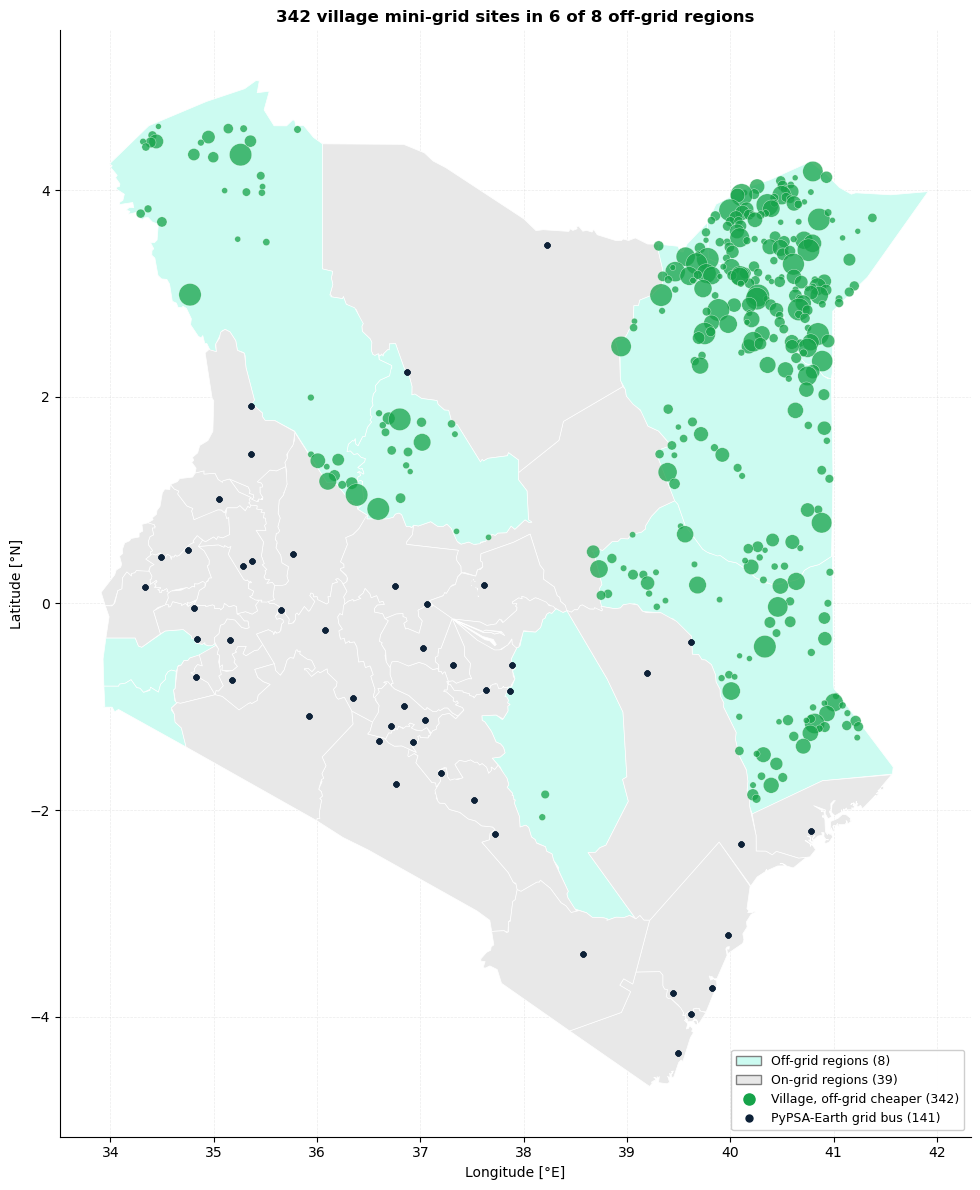

villages plotted : 342 (342 off-grid cheaper, 0 grid cheaper)
marker size      : population 703 - 14,598
extent           : lon 34.29 - 41.38, lat -2.07 - 4.62


In [34]:
# ── Figure: map of village mini-grid sites ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import geopandas as gpd

SHAPES_FILE = "resources/shapes/gadm_shapes.geojson"

shapes = gpd.read_file(SHAPES_FILE)
offgrid_ids = set(county.region)
main_buses = n.buses.loc[
    [b for b in n.buses.index if not b.startswith("offgrid_")], ["x", "y"]
]

C_OFFGRID_CTY, C_ONGRID_CTY = "#CCFBF1", "#e8e8e8"
C_CHEAPER, C_GRID_CHEAPER, C_BUS = "#16a34a", "#dc2626", "#0D2137"

fig, ax = plt.subplots(figsize=(11, 12))

shapes.plot(
    ax=ax,
    color=[C_OFFGRID_CTY if i in offgrid_ids else C_ONGRID_CTY for i in shapes.GADM_ID],
    edgecolor="white",
    linewidth=0.5,
    zorder=1,
)

ax.scatter(main_buses.x, main_buses.y, s=12, color=C_BUS, zorder=4)

cheap = village[village.offgrid_cheaper]
exp = village[~village.offgrid_cheaper]
for sub, col in [(cheap, C_CHEAPER), (exp, C_GRID_CHEAPER)]:
    if len(sub):
        ax.scatter(
            sub.centroid_x,
            sub.centroid_y,
            s=np.clip(sub.population / 40, 12, 260),
            color=col,
            alpha=0.75,
            edgecolor="white",
            linewidth=0.3,
            zorder=5,
        )

ax.set_xlabel("Longitude [°E]")
ax.set_ylabel("Latitude [°N]")
ax.set_aspect("equal")
ax.grid(alpha=0.25, linestyle="--", linewidth=0.5)
ax.set_axisbelow(True)
ax.set_title(
    f"{len(village)} village mini-grid sites in "
    f"{village.gadm_id.nunique()} of {len(offgrid_ids)} off-grid regions",
    fontsize=12,
    fontweight="bold",
)

handles = [
    mpatches.Patch(
        facecolor=C_OFFGRID_CTY,
        edgecolor="grey",
        label=f"Off-grid regions ({len(offgrid_ids)})",
    ),
    mpatches.Patch(
        facecolor=C_ONGRID_CTY,
        edgecolor="grey",
        label=f"On-grid regions ({len(shapes) - len(offgrid_ids)})",
    ),
    mlines.Line2D(
        [],
        [],
        marker="o",
        color=C_CHEAPER,
        linestyle="None",
        markersize=8,
        label=f"Village, off-grid cheaper ({len(cheap)})",
    ),
    mlines.Line2D(
        [],
        [],
        marker="o",
        color=C_BUS,
        linestyle="None",
        markersize=5,
        label=f"PyPSA-Earth grid bus ({len(main_buses)})",
    ),
]
if len(exp):
    handles.insert(
        3,
        mlines.Line2D(
            [],
            [],
            marker="o",
            color=C_GRID_CHEAPER,
            linestyle="None",
            markersize=8,
            label=f"Village, grid cheaper ({len(exp)})",
        ),
    )
ax.legend(handles=handles, loc="lower right", fontsize=9, framealpha=0.95)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGDIR}/village_minigrids_map.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/village_minigrids_map.pdf", bbox_inches="tight")
plt.show()

print(
    f"villages plotted : {len(village)} "
    f"({len(cheap)} off-grid cheaper, {len(exp)} grid cheaper)"
)
print(
    f"marker size      : population {village.population.min():,} - "
    f"{village.population.max():,}"
)
print(
    f"extent           : lon {village.centroid_x.min():.2f} - "
    f"{village.centroid_x.max():.2f}, lat "
    f"{village.centroid_y.min():.2f} - {village.centroid_y.max():.2f}"
)

## 4.3 Comparison: county vs village level

Both scales compared for the six regions where results exist at both. The
per-capita normalisation matters here: the village layer covers only part of each
county's population, so absolute capacities are not directly comparable.

build the comparison frame

In [35]:
# ── County vs village comparison ─────────────────────────────────
SHARED_REGIONS = sorted(set(village.gadm_id) & set(county.region))
REGION_ORDER = ["KE.7_1", "KE.18_1", "KE.24_1", "KE.37_1", "KE.43_1", "KE.46_1"]
assert set(REGION_ORDER) == set(SHARED_REGIONS), "region list out of date"

cty = county.set_index("region").loc[REGION_ORDER]
vil = (
    village.groupby("gadm_id")
    .agg(
        villages=("village_id", "count"),
        population=("population", "sum"),
        solar_kw=("solar_kw", "sum"),
        battery_kw=("battery_kw", "sum"),
        battery_kwh=("battery_kwh", "sum"),
        diesel_kw=("diesel_kw", "sum"),
        lcoe=(LCOE_COL, "mean"),
    )
    .loc[REGION_ORDER]
)

cmp_ = pd.DataFrame(
    {
        "c_pop": cty.population,
        "c_solar_mw": cty.solar_kw / 1000,
        "c_cost_keur": cty.total_cost_keur_yr,
        "c_w_cap": cty.solar_kw * 1000 / cty.population,
        "c_lcoe": cty.lcoe_eur_kwh,
        "c_storage_h": cty.battery_kwh / cty.solar_kw,
        "v_n": vil.villages,
        "v_pop": vil.population,
        "v_solar_mw": vil.solar_kw / 1000,
        "v_w_cap": vil.solar_kw * 1000 / vil.population,
        "v_lcoe": vil.lcoe,
        "v_storage_h": vil.battery_kwh / vil.solar_kw,
    }
)
cmp_["coverage_pct"] = cmp_.v_pop / cmp_.c_pop * 100
display(cmp_.round(3))

CAPEX = {
    "solar": cfg["solar_capex"],
    "battery": cfg["battery_capex_kwh"],
    "diesel": cfg["diesel_capex"],
}


def _batt_share(solar_kw, battery_kwh, diesel_kw):
    s = solar_kw * CAPEX["solar"]
    b = battery_kwh * CAPEX["battery"]
    d = diesel_kw * CAPEX["diesel"]
    return b / (s + b + d) * 100


# aggregates computed from raw capacities, not from means of the columns above
AGG = {
    "c_pop": cty.population.sum(),
    "v_pop": vil.population.sum(),
    "c_solar_mw": cty.solar_kw.sum() / 1000,
    "v_solar_mw": vil.solar_kw.sum() / 1000,
    "v_n": int(vil.villages.sum()),
    "c_w_cap": cty.solar_kw.sum() * 1000 / cty.population.sum(),
    "v_w_cap": vil.solar_kw.sum() * 1000 / vil.population.sum(),
    "c_lcoe": cty.lcoe_eur_kwh.mean(),
    "v_lcoe": village[village.gadm_id.isin(REGION_ORDER)][LCOE_COL].mean(),
    "c_storage_h": cty.battery_kwh.sum() / cty.solar_kw.sum(),
    "v_storage_h": vil.battery_kwh.sum() / vil.solar_kw.sum(),
    "c_batt_share": _batt_share(
        cty.solar_kw.sum(), cty.battery_kwh.sum(), cty.diesel_kw.sum()
    ),
    "v_batt_share": _batt_share(
        vil.solar_kw.sum(), vil.battery_kwh.sum(), vil.diesel_kw.sum()
    ),
}
AGG["coverage_pct"] = AGG["v_pop"] / AGG["c_pop"] * 100

print("\nfigures quoted in the section text")
print(
    f"  coverage            : {AGG['coverage_pct']:.1f} % "
    f"({cmp_.coverage_pct.min():.1f} - {cmp_.coverage_pct.max():.1f} by region)"
)
print(
    f"  solar per capita    : county {cmp_.c_w_cap.min():.1f}-{cmp_.c_w_cap.max():.1f} W"
    f" | village {cmp_.v_w_cap.min():.1f}-{cmp_.v_w_cap.max():.1f} W"
)
print(
    f"  village higher in   : {int((cmp_.v_w_cap > cmp_.c_w_cap).sum())}/{len(cmp_)} regions"
)
print(
    f"  LCOE                : county {AGG['c_lcoe']:.3f} | village {AGG['v_lcoe']:.3f} "
    f"EUR/kWh  (+{(AGG['c_lcoe']/AGG['v_lcoe'] - 1)*100:.0f} %)"
)
print(
    f"  storage duration    : county {AGG['c_storage_h']:.2f} h | "
    f"village {AGG['v_storage_h']:.2f} h per MW PV"
)
print(
    f"  battery CAPEX share : county {AGG['c_batt_share']:.1f} % | "
    f"village {AGG['v_batt_share']:.1f} %"
)
print(
    f"  county cost range   : {cty.total_cost_keur_yr.min()/1000:.2f} - "
    f"{cty.total_cost_keur_yr.max()/1000:.2f} MEUR/a"
)
print(
    f"  village system size : {village.solar_kw.min():.1f} - "
    f"{village.solar_kw.max():.1f} kW solar"
)

,c_pop,c_solar_mw,c_cost_keur,c_w_cap,c_lcoe,c_storage_h,v_n,v_pop,v_solar_mw,v_w_cap,v_lcoe,v_storage_h,coverage_pct
KE.7_1,1515744,51.449,16567.4,33.943,0.182,8.627,70,186099,7.234,38.870,0.107,2.564,12.278
KE.18_1,1237267,42.290,13740.2,34.180,0.185,8.586,2,2480,0.107,43.149,0.115,2.320,0.200
KE.24_1,2599168,97.745,29638.6,37.606,0.190,7.736,115,401688,17.346,43.182,0.117,2.331,15.454
KE.37_1,319392,11.256,3531.3,35.240,0.184,8.333,17,50232,1.858,36.995,0.103,2.683,15.727
KE.43_1,1209489,37.356,13104.8,30.886,0.181,9.614,36,101546,3.594,35.389,0.100,2.824,8.396
KE.46_1,1695325,62.102,18941.8,36.631,0.186,7.944,102,357091,15.152,42.431,0.114,2.361,21.063



figures quoted in the section text
  coverage            : 12.8 % (0.2 - 21.1 by region)
  solar per capita    : county 30.9-37.6 W | village 35.4-43.2 W
  village higher in   : 6/6 regions
  LCOE                : county 0.185 | village 0.111 EUR/kWh  (+66 %)
  storage duration    : county 8.30 h | village 2.43 h per MW PV
  battery CAPEX share : county 71.8 % | village 42.5 %
  county cost range   : 3.53 - 29.64 MEUR/a
  village system size : 23.8 - 632.1 kW solar


scale and coverage

In [36]:
# ── Table A: scale and coverage ──────────────────────────────────
table_a = pd.DataFrame(
    {
        ("County level", "Population"): cmp_.c_pop,
        ("County level", "Solar [MW]"): cmp_.c_solar_mw.round(1),
        ("Village level", "Villages"): cmp_.v_n,
        ("Village level", "Population"): cmp_.v_pop,
        ("Village level", "Solar [MW]"): cmp_.v_solar_mw.round(2),
        ("", "Coverage [%]"): cmp_.coverage_pct.round(1),
    }
)
table_a.loc["Total"] = [
    AGG["c_pop"],
    round(AGG["c_solar_mw"], 1),
    AGG["v_n"],
    AGG["v_pop"],
    round(AGG["v_solar_mw"], 2),
    round(AGG["coverage_pct"], 1),
]
for _col in [
    ("County level", "Population"),
    ("Village level", "Villages"),
    ("Village level", "Population"),
]:
    table_a[_col] = table_a[_col].astype("int64")
table_a.index.name = "Region"

display(table_a)

County level            Village level                                   
          Population Solar [MW]      Villages Population Solar [MW] Coverage [%]
Region                                                                          
KE.7_1       1515744       51.4            70     186099       7.23         12.3
KE.18_1      1237267       42.3             2       2480       0.11          0.2
KE.24_1      2599168       97.7           115     401688      17.35         15.5
KE.37_1       319392       11.3            17      50232       1.86         15.7
KE.43_1      1209489       37.4            36     101546       3.59          8.4
KE.46_1      1695325       62.1           102     357091      15.15         21.1
Total        8576385      302.2           342    1099136      45.29         12.8

normalised characteristics

In [37]:
# ── Table B: normalised characteristics ──────────────────────────
table_b = pd.DataFrame(
    {
        ("Solar per capita [W]", "County"): cmp_.c_w_cap.round(1),
        ("Solar per capita [W]", "Village"): cmp_.v_w_cap.round(1),
        ("LCOE [EUR/kWh]", "County"): cmp_.c_lcoe.round(3),
        ("LCOE [EUR/kWh]", "Village"): cmp_.v_lcoe.round(3),
        ("Storage [h per MW PV]", "County"): cmp_.c_storage_h.round(2),
        ("Storage [h per MW PV]", "Village"): cmp_.v_storage_h.round(2),
    }
)
table_b.loc["Aggregate"] = [
    round(AGG["c_w_cap"], 1),
    round(AGG["v_w_cap"], 1),
    round(AGG["c_lcoe"], 3),
    round(AGG["v_lcoe"], 3),
    round(AGG["c_storage_h"], 2),
    round(AGG["v_storage_h"], 2),
]
table_b.index.name = "Region"

display(table_b)

Solar per capita [W]         LCOE [EUR/kWh]         Storage [h per MW PV]        
                        County Village         County Village                County Village
Region                                                                                     
KE.7_1                    33.9    38.9          0.182   0.107                  8.63    2.56
KE.18_1                   34.2    43.1          0.185   0.115                  8.59    2.32
KE.24_1                   37.6    43.2          0.190   0.117                  7.74    2.33
KE.37_1                   35.2    37.0          0.184   0.103                  8.33    2.68
KE.43_1                   30.9    35.4          0.181   0.100                  9.61    2.82
KE.46_1                   36.6    42.4          0.186   0.114                  7.94    2.36
Aggregate                 35.2    41.2          0.185   0.111                  8.30    2.43

dispatch time series for one off-grid region

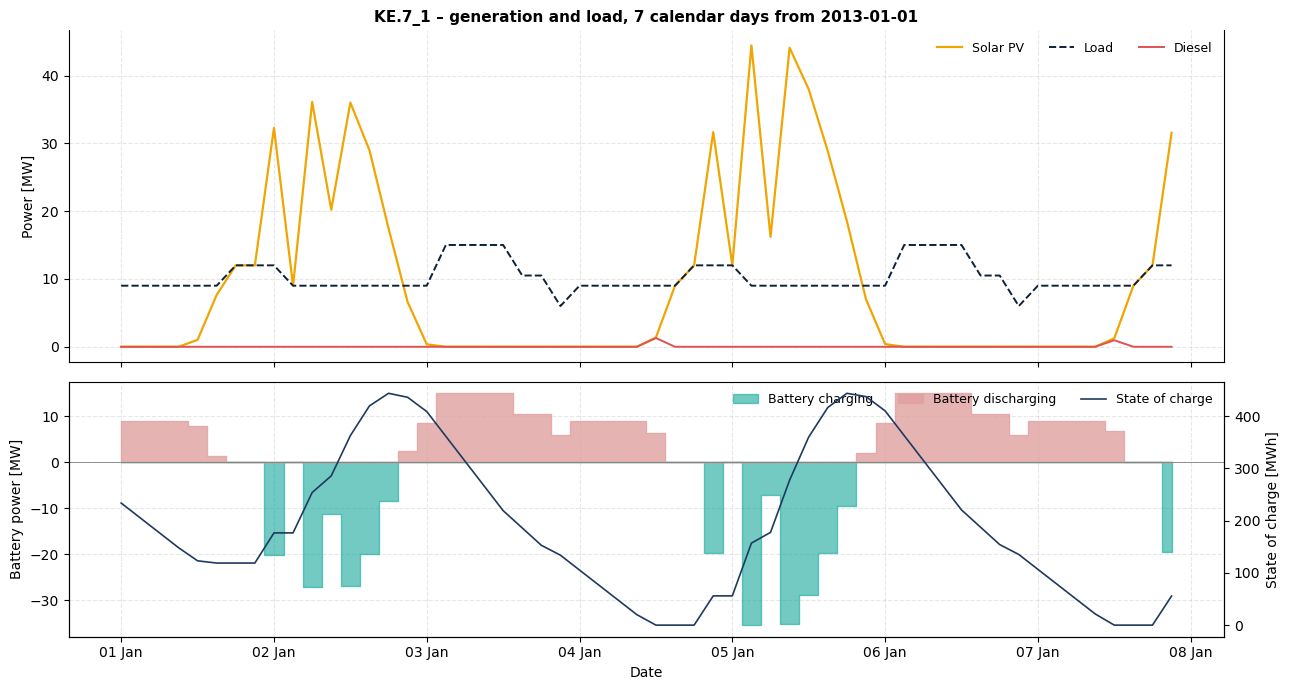

periodicity of the modelled load profile
  lag  8 snapshots =  24 h : autocorrelation -0.358
  lag 16 snapshots =  48 h : autocorrelation -0.358
  lag 24 snapshots =  72 h : autocorrelation +1.000

daylight periods in window : 3
calendar days in window    : 7
-> one modelled day spans  : 56 real hours


In [38]:
# ── Figure: dispatch time series for one off-grid region ─────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

REGION = "KE.7_1"
START, DAYS = "2013-01-01", 7  # real calendar days

win = n.snapshots[
    (n.snapshots >= pd.Timestamp(START))
    & (n.snapshots < pd.Timestamp(START) + pd.Timedelta(days=DAYS))
]

solar = n.generators_t.p.loc[win, f"solar_{REGION}"]
diesel = n.generators_t.p.loc[win, f"diesel_{REGION}"]
load = n.loads_t.p_set.loc[win, f"load_{REGION}"]
bat = n.storage_units_t.p.loc[win, f"battery_{REGION}"]
soc = n.storage_units_t.state_of_charge.loc[win, f"battery_{REGION}"]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [1.3, 1]}
)

ax1.plot(win, solar, color="#f0a500", lw=1.6, label="Solar PV")
ax1.plot(win, load, color="#0D2137", lw=1.4, ls="--", label="Load")
ax1.plot(win, diesel, color="#e05252", lw=1.4, label="Diesel")
ax1.set_ylabel("Power [MW]")
ax1.set_title(
    f"{REGION} – generation and load, {DAYS} calendar days from {START}",
    fontsize=11,
    fontweight="bold",
)
ax1.legend(frameon=False, fontsize=9, ncol=3)
ax1.grid(alpha=0.3, ls="--")
ax1.set_axisbelow(True)

ax2.fill_between(
    win,
    bat.clip(upper=0),
    0,
    color="#14a89a",
    alpha=0.6,
    step="mid",
    label="Battery charging",
)
ax2.fill_between(
    win,
    bat.clip(lower=0),
    0,
    color="#e0a0a0",
    alpha=0.8,
    step="mid",
    label="Battery discharging",
)
ax2.axhline(0, color="grey", lw=0.6)
ax2.set_ylabel("Battery power [MW]")
ax2.grid(alpha=0.3, ls="--")
ax2.set_axisbelow(True)

ax3 = ax2.twinx()
ax3.plot(win, soc, color="#1e3a5f", lw=1.2, label="State of charge")
ax3.set_ylabel("State of charge [MWh]")

h2, l2 = ax2.get_legend_handles_labels()
h3, l3 = ax3.get_legend_handles_labels()
ax2.legend(h2 + h3, l2 + l3, frameon=False, fontsize=9, ncol=3, loc="upper right")

ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.set_xlabel("Date")
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGDIR}/offgrid_timeseries.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{FIGDIR}/offgrid_timeseries.pdf", bbox_inches="tight")
plt.show()

# diagnostic: how long is one modelled day?
prof = n.loads_t.p_set[f"load_{REGION}"]
x = prof.values - prof.values.mean()
print("periodicity of the modelled load profile")
for lag in [8, 16, 24]:
    ac = np.corrcoef(x[:-lag], x[lag:])[0, 1]
    print(
        f"  lag {lag:>2} snapshots = {lag*int(W.iloc[0]):>3} h : "
        f"autocorrelation {ac:+.3f}"
    )

sp = n.generators_t.p_max_pu[f"solar_{REGION}"].loc[win].values > 0.01
n_daylight = int(((~sp[:-1]) & sp[1:]).sum()) + int(sp[0])
print(f"\ndaylight periods in window : {n_daylight}")
print(f"calendar days in window    : {DAYS}")
print(f"-> one modelled day spans  : {DAYS*24/max(n_daylight,1):.0f} real hours")

---

*Next items to be added: Figure – geo-logic map, Figure – CAPEX breakdown and
cost comparison, Figure – county KPIs, then Sections 4.2 onwards.*